In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [2]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [3]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


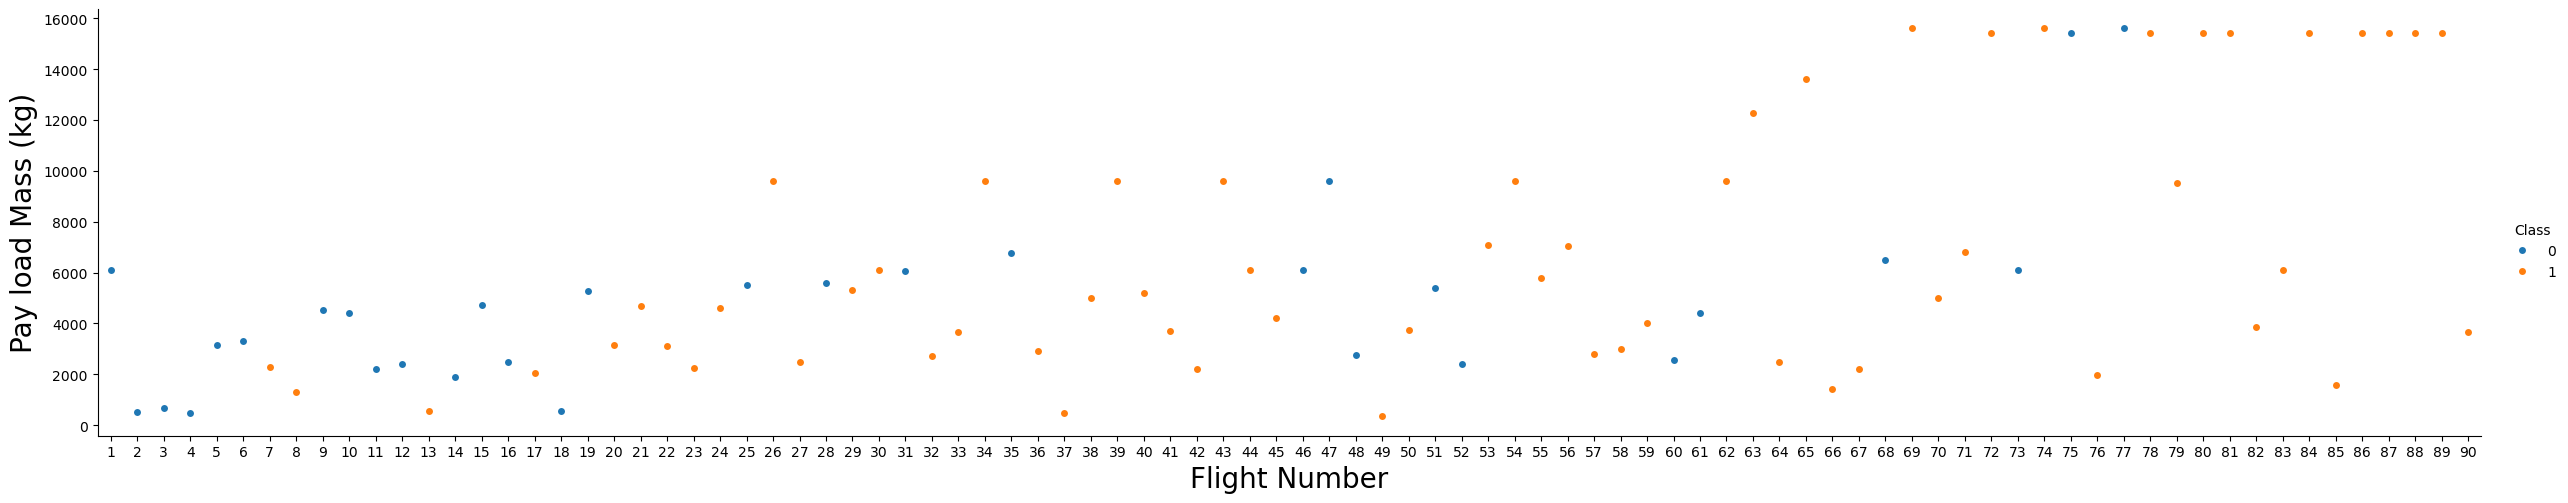

In [4]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

In [6]:
print(df.columns)

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class'],
      dtype='object')


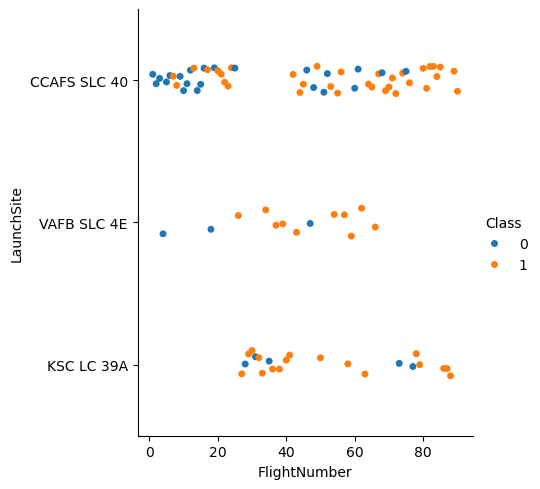

In [7]:
sns.catplot(
    x='FlightNumber',
    y='LaunchSite',
    hue='Class',
    data=df,
    kind='strip'
)

plt.show()

👉 Launch success improves significantly with increasing flight number, indicating strong learning and system optimization over time.

👉 Early failures are concentrated in initial launches, particularly at CCAFS sites.

👉 KSC LC-39A shows consistently high success rates, suggesting either improved infrastructure or more mature missions.

👉 Overall, launch reliability becomes more consistent across all sites as experience increases.

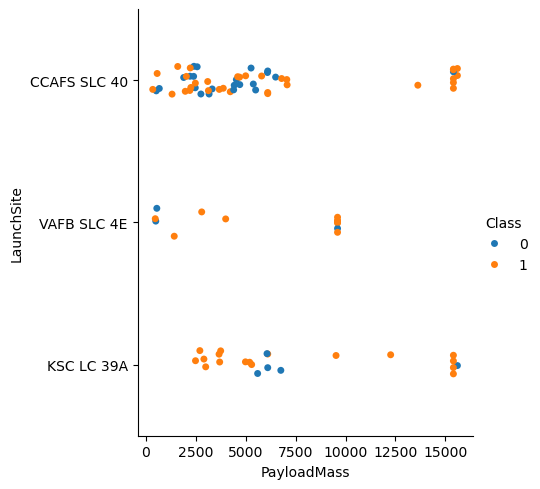

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    x='PayloadMass',
    y='LaunchSite',
    hue='Class',
    data=df,
    kind='strip'
)

plt.show()

In [9]:
success_rate = df.groupby('Orbit')['Class'].mean().reset_index()

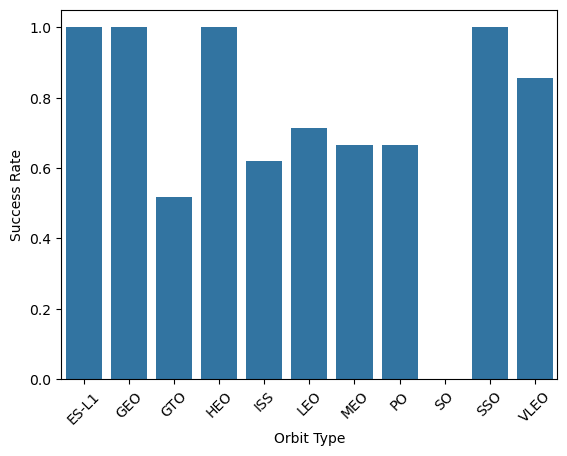

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='Orbit',
    y='Class',
    data=success_rate
)

plt.xticks(rotation=45)
plt.ylabel('Success Rate')
plt.xlabel('Orbit Type')

plt.show()

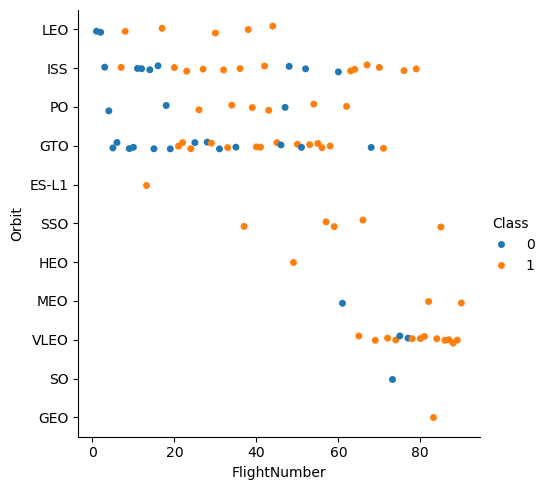

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    x='FlightNumber',
    y='Orbit',
    hue='Class',
    data=df,
    kind='strip'
)

plt.show()

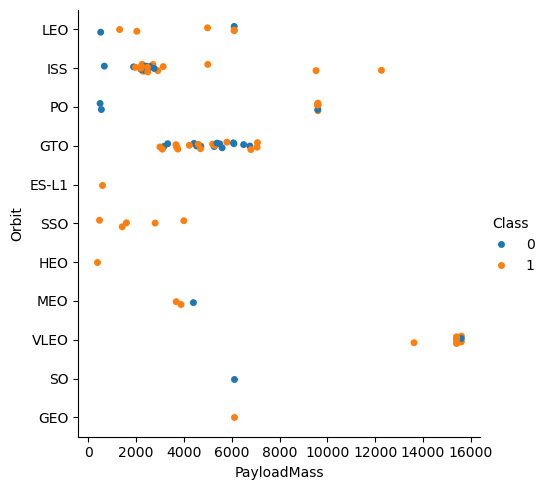

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    x='PayloadMass',
    y='Orbit',
    hue='Class',
    data=df,
    kind='strip'
)

plt.show()

In [13]:
df['Year'] = df['Date'].str.split("-").str[0]

In [14]:
df['Year'] = df['Year'].astype(int)

In [15]:
yearly_success = df.groupby('Year')['Class'].mean().reset_index()

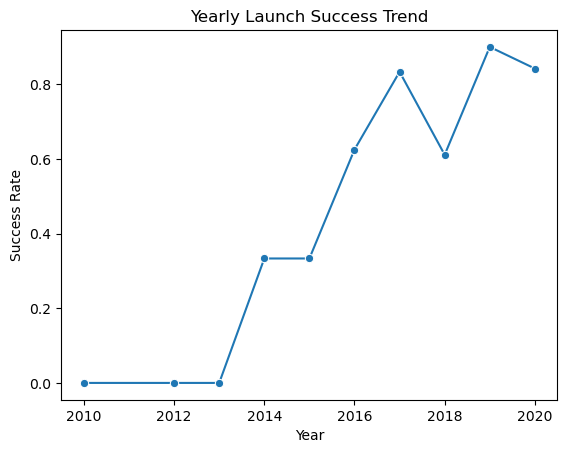

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    x='Year',
    y='Class',
    data=yearly_success,
    marker='o'
)

plt.ylabel('Success Rate')
plt.xlabel('Year')
plt.title('Yearly Launch Success Trend')

plt.show()

In [17]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [18]:
features_one_hot = pd.get_dummies(
    df,
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
)

features_one_hot.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Outcome,Flights,GridFins,Reused,Legs,Block,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,2010-06-04,Falcon 9,6104.959412,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
1,2,2012-05-22,Falcon 9,525.000000,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
2,3,2013-03-01,Falcon 9,677.000000,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
3,4,2013-09-29,Falcon 9,500.000000,False Ocean,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
4,5,2013-12-03,Falcon 9,3170.000000,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False


In [20]:
features_one_hot.dtypes

FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Outcome            object
                   ...   
Serial_B1056         bool
Serial_B1058         bool
Serial_B1059         bool
Serial_B1060         bool
Serial_B1062         bool
Length: 87, dtype: object

In [21]:
features_one_hot = features_one_hot.drop(columns=['Date'])

In [23]:
features_one_hot.select_dtypes(include='object').columns

Index(['BoosterVersion', 'Outcome'], dtype='object')

In [24]:
features_one_hot = features_one_hot.drop(
    columns=features_one_hot.select_dtypes(include='object').columns
)

In [25]:
features_one_hot = features_one_hot.astype('float64')

In [26]:
features_one_hot.to_csv('spacex_features.csv', index=False)